<a href="https://colab.research.google.com/github/Alisha-bhatti/DEEP-LEARNING-FOR-NATURAL-LANGUAGE-PROCESSING/blob/main/Pretrained_Embedding_Visualization_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim scikit-learn matplotlib
import numpy as np
import matplotlib.pyplot as plt
from gensim import downloader as api
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.0 MB/s eta 0:00:00


In [2]:
print("Loading pretrained GloVe embeddings...")
model = api.load("glove-wiki-gigaword-100")
print("Model loaded successfully!")


Loading pretrained GloVe embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Model loaded successfully!


In [3]:
words = [
    "king", "queen", "man", "woman",
    "prince", "princess",
    "apple", "banana", "orange",
    "paris", "france", "london", "england",
    "computer", "laptop", "software", "hardware"
]


In [4]:
embeddings = []
valid_words = []
for word in words:
    if word in model:
        embeddings.append(model[word])
        valid_words.append(word)
embeddings = np.array(embeddings)
print(f"Number of valid words: {len(valid_words)}")


Number of valid words: 17


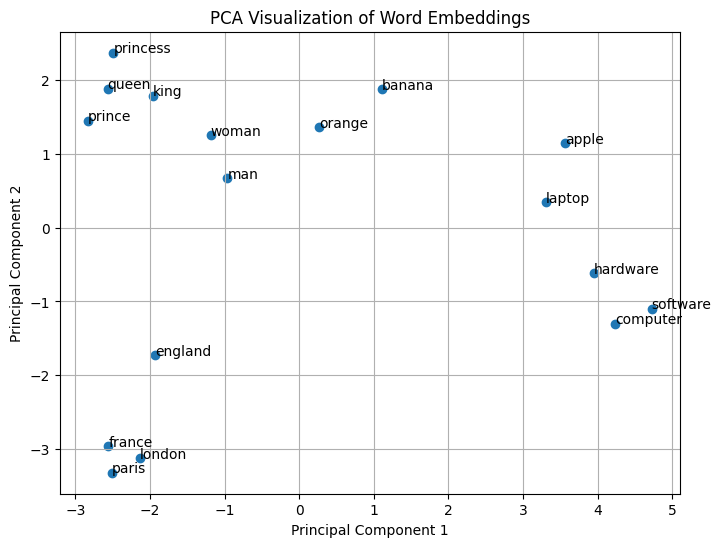

In [5]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]))
plt.title("PCA Visualization of Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


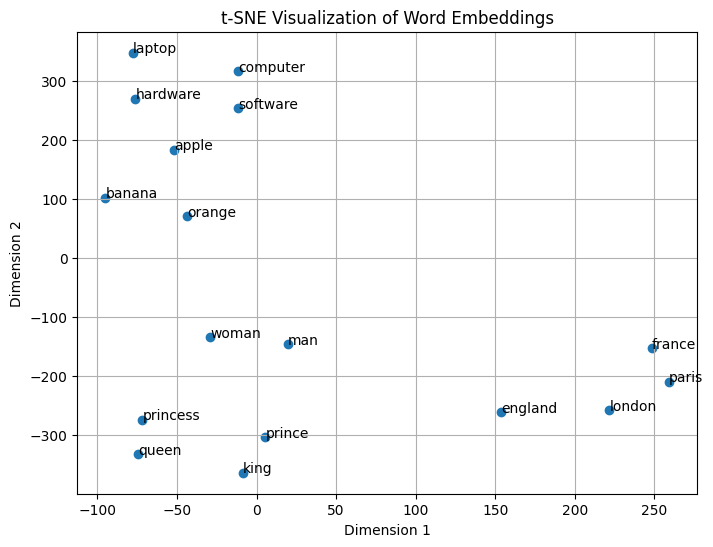

In [6]:
tsne = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)
tsne_result = tsne.fit_transform(embeddings)
plt.figure(figsize=(8, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (tsne_result[i, 0], tsne_result[i, 1]))
plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
